In [1]:
# HELPER IMPORTS AND FUNCTIONS FOR CHAPTER 8 EXERCISES.
# ---------------------------------------------------------------------
# This cell collects the common imports, plotting configuration, dataset
# loaders, PCA helpers, linear-autoencoder helpers, and K-means helpers used
# across the Chapter 8 exercises so the later cells can stay focused on the
# exercise-specific logic.
# ---------------------------------------------------------------------

import numpy as np
import autograd.numpy as anp
from autograd import value_and_grad
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

SPAN_DATA_PATH = Path("..") / "chapter_8_datasets" / "2d_span_data.csv"
CLUSTER_DATA_PATH = Path("..") / "chapter_8_datasets" / "5cluster_2d_data.csv"

def load_span_data():
    return np.loadtxt(SPAN_DATA_PATH, delimiter=",")

def load_centered_span_data():
    X_raw = load_span_data()
    X_centered = X_raw - X_raw.mean(axis=1, keepdims=True)
    return X_raw, X_centered

def load_cluster_data():
    return np.loadtxt(CLUSTER_DATA_PATH, delimiter=",")

def center_data(X):
    X_means = np.mean(X, axis=1, keepdims=True)
    return X - X_means, X_means

def compute_pcs(X_centered, lam=0.0):
    num_points = float(X_centered.shape[1])
    covariance = (X_centered @ X_centered.T) / num_points + lam * np.eye(X_centered.shape[0])
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = np.argsort(eigenvalues)[::-1]
    return eigenvalues[order], eigenvectors[:, order]

def linear_autoencoder_cost_from_covariance(c, covariance):
    c = np.asarray(c).reshape(2, 1)
    quadratic_term = (c.T @ covariance @ c).item()
    norm_squared = (c.T @ c).item()
    return np.trace(covariance) - 2.0 * quadratic_term + norm_squared * quadratic_term

def linear_autoencoder_cost_autograd(c_flat, X_centered_ag):
    c = anp.reshape(c_flat, (2, 1))
    encoded_data = anp.dot(c.T, X_centered_ag)
    decoded_data = anp.dot(c, encoded_data)
    reconstruction_errors = decoded_data - X_centered_ag
    return anp.mean(anp.sum(reconstruction_errors ** 2, axis=0))

def gradient_descent_autograd(cost_fn, cost_and_grad_fn, c_init, alpha, max_its):
    c = anp.array(c_init, dtype=float)
    c_history = [np.asarray(c, dtype=float).copy()]
    cost_history = [float(cost_fn(c))]
    for _ in range(max_its):
        _, grad_value = cost_and_grad_fn(c)
        c = c - alpha * grad_value
        c_history.append(np.asarray(c, dtype=float).copy())
        cost_history.append(float(cost_fn(c)))
    return np.array(c_history), np.array(cost_history)

def assign_clusters(data, centroids):
    diffs = data[:, :, None] - centroids[:, None, :]
    squared_distances = np.sum(diffs ** 2, axis=0)
    return np.argmin(squared_distances, axis=1)

def update_centroids(data, assignments, old_centroids):
    centroids = old_centroids.copy()
    for k in range(old_centroids.shape[1]):
        cluster_points = data[:, assignments == k]
        if cluster_points.shape[1] > 0:
            centroids[:, k] = np.mean(cluster_points, axis=1)
    return centroids

def kmeans_objective(data, centroids, assignments):
    total_error = 0.0
    for k in range(centroids.shape[1]):
        cluster_points = data[:, assignments == k]
        if cluster_points.shape[1] > 0:
            diffs = cluster_points - centroids[:, [k]]
            total_error += np.sum(diffs ** 2)
    return total_error / data.shape[1]

def run_kmeans(data, init_centroids, max_its=50, return_history=False):
    centroids = init_centroids.copy()
    previous_assignments = None
    objective_history = []
    for _ in range(max_its):
        assignments = assign_clusters(data, centroids)
        objective_history.append(kmeans_objective(data, centroids, assignments))
        if previous_assignments is not None and np.array_equal(assignments, previous_assignments):
            break
        previous_assignments = assignments.copy()
        new_centroids = update_centroids(data, assignments, centroids)
        if np.allclose(new_centroids, centroids):
            centroids = new_centroids
            break
        centroids = new_centroids
    assignments = assign_clusters(data, centroids)
    final_objective = kmeans_objective(data, centroids, assignments)
    objective_history.append(final_objective)
    if return_history:
        return centroids, assignments, np.array(objective_history)
    return centroids, assignments, final_objective

Loaded data matrix shape: (2, 50)
Encoding matrix shape: (2, 50)
Maximum reconstruction error: 3.55e-15


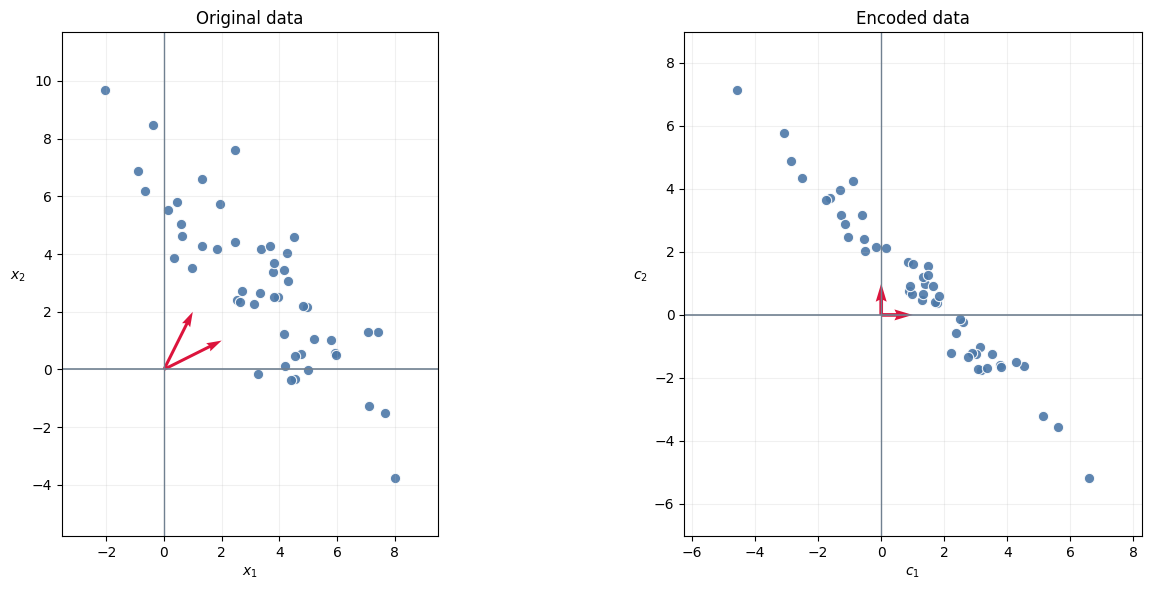

In [2]:
# QUESTION HANDLED: Exercise 8.2 - Encoding data.
# ---------------------------------------------------------------------
# Reproduce the Example 8.1 / Figure 8.2 style encoding demonstration using
# the Chapter 8 toy dataset and the fixed spanning matrix
#
#     C = [[2, 1],
#          [1, 2]]
#
# The left panel shows the original data in x-space together with the two
# spanning vectors.  The right panel shows the encoded coordinates c-space,
# obtained by solving the least-squares encoding problem for every point.
# ---------------------------------------------------------------------
# Textbook equations used here: the encoding least-squares objective in Equation (8.7)
# and the encoder/decoder relationship discussed around Equation (8.11).

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
# HELPER IMPORTS AND FUNCTIONS FOR CHAPTER 8 EXERCISES.
# ---------------------------------------------------------------------
# This same cell collects the common imports, plotting configuration, dataset
# loaders, PCA helpers, linear-autoencoder helpers, and K-means helpers used
# across the Chapter 8 exercises so the later cells can stay focused on the
# exercise-specific logic.
# ---------------------------------------------------------------------

import numpy as np
import autograd.numpy as anp
from autograd import value_and_grad
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

SPAN_DATA_PATH = Path("..") / "chapter_8_datasets" / "2d_span_data.csv"
CLUSTER_DATA_PATH = Path("..") / "chapter_8_datasets" / "5cluster_2d_data.csv"

def load_span_data():
    return np.loadtxt(SPAN_DATA_PATH, delimiter=",")

def load_centered_span_data():
    X_raw = load_span_data()
    X_centered = X_raw - X_raw.mean(axis=1, keepdims=True)
    return X_raw, X_centered

def load_cluster_data():
    return np.loadtxt(CLUSTER_DATA_PATH, delimiter=",")

def center_data(X):
    X_means = np.mean(X, axis=1, keepdims=True)
    return X - X_means, X_means

def compute_pcs(X_centered, lam=0.0):
    num_points = float(X_centered.shape[1])
    covariance = (X_centered @ X_centered.T) / num_points + lam * np.eye(X_centered.shape[0])
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = np.argsort(eigenvalues)[::-1]
    return eigenvalues[order], eigenvectors[:, order]

def linear_autoencoder_cost_from_covariance(c, covariance):
    c = np.asarray(c).reshape(2, 1)
    quadratic_term = (c.T @ covariance @ c).item()
    norm_squared = (c.T @ c).item()
    return np.trace(covariance) - 2.0 * quadratic_term + norm_squared * quadratic_term

def linear_autoencoder_cost_autograd(c_flat, X_centered_ag):
    c = anp.reshape(c_flat, (2, 1))
    encoded_data = anp.dot(c.T, X_centered_ag)
    decoded_data = anp.dot(c, encoded_data)
    reconstruction_errors = decoded_data - X_centered_ag
    return anp.mean(anp.sum(reconstruction_errors ** 2, axis=0))

def gradient_descent_autograd(cost_fn, cost_and_grad_fn, c_init, alpha, max_its):
    c = anp.array(c_init, dtype=float)
    c_history = [np.asarray(c, dtype=float).copy()]
    cost_history = [float(cost_fn(c))]
    for _ in range(max_its):
        _, grad_value = cost_and_grad_fn(c)
        c = c - alpha * grad_value
        c_history.append(np.asarray(c, dtype=float).copy())
        cost_history.append(float(cost_fn(c)))
    return np.array(c_history), np.array(cost_history)

def assign_clusters(data, centroids):
    diffs = data[:, :, None] - centroids[:, None, :]
    squared_distances = np.sum(diffs ** 2, axis=0)
    return np.argmin(squared_distances, axis=1)

def update_centroids(data, assignments, old_centroids):
    centroids = old_centroids.copy()
    for k in range(old_centroids.shape[1]):
        cluster_points = data[:, assignments == k]
        if cluster_points.shape[1] > 0:
            centroids[:, k] = np.mean(cluster_points, axis=1)
    return centroids

def kmeans_objective(data, centroids, assignments):
    total_error = 0.0
    for k in range(centroids.shape[1]):
        cluster_points = data[:, assignments == k]
        if cluster_points.shape[1] > 0:
            diffs = cluster_points - centroids[:, [k]]
            total_error += np.sum(diffs ** 2)
    return total_error / data.shape[1]

def run_kmeans(data, init_centroids, max_its=50, return_history=False):
    centroids = init_centroids.copy()
    previous_assignments = None
    objective_history = []
    for _ in range(max_its):
        assignments = assign_clusters(data, centroids)
        objective_history.append(kmeans_objective(data, centroids, assignments))
        if previous_assignments is not None and np.array_equal(assignments, previous_assignments):
            break
        previous_assignments = assignments.copy()
        new_centroids = update_centroids(data, assignments, centroids)
        if np.allclose(new_centroids, centroids):
            centroids = new_centroids
            break
        centroids = new_centroids
    assignments = assign_clusters(data, centroids)
    final_objective = kmeans_objective(data, centroids, assignments)
    objective_history.append(final_objective)
    if return_history:
        return centroids, assignments, np.array(objective_history)
    return centroids, assignments, final_objective

X = load_span_data()

C = np.array([
    [2.0, 1.0],
    [1.0, 2.0],
])

W = np.linalg.solve(C.T @ C, C.T @ X)
X_decoded = C @ W
max_reconstruction_error = np.max(np.abs(X - X_decoded))

print(f"Loaded data matrix shape: {X.shape}")
print(f"Encoding matrix shape: {W.shape}")
print(f"Maximum reconstruction error: {max_reconstruction_error:.2e}")

point_color = "#4C78A8"
vector_color = "crimson"
axis_color = "slategray"

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X[0, :], X[1, :], s=55, color=point_color, edgecolor="white", linewidth=0.8, alpha=0.9)
axes[0].quiver(0, 0, C[0, 0], C[1, 0], angles="xy", scale_units="xy", scale=1, color=vector_color, width=0.008)
axes[0].quiver(0, 0, C[0, 1], C[1, 1], angles="xy", scale_units="xy", scale=1, color=vector_color, width=0.008)
axes[0].axhline(0, color=axis_color, linewidth=1.2)
axes[0].axvline(0, color=axis_color, linewidth=1.0)
axes[0].set_title("Original data")
axes[0].set_xlabel(r"$x_1$")
axes[0].set_ylabel(r"$x_2$", rotation=0, labelpad=10)
axes[0].set_aspect("equal", adjustable="box")

axes[1].scatter(W[0, :], W[1, :], s=55, color=point_color, edgecolor="white", linewidth=0.8, alpha=0.9)
axes[1].quiver(0, 0, 1, 0, angles="xy", scale_units="xy", scale=1, color=vector_color, width=0.008)
axes[1].quiver(0, 0, 0, 1, angles="xy", scale_units="xy", scale=1, color=vector_color, width=0.008)
axes[1].axhline(0, color=axis_color, linewidth=1.2)
axes[1].axvline(0, color=axis_color, linewidth=1.0)
axes[1].set_title("Encoded data")
axes[1].set_xlabel(r"$c_1$")
axes[1].set_ylabel(r"$c_2$", rotation=0, labelpad=10)
axes[1].set_aspect("equal", adjustable="box")

for ax, data in zip(axes, [X, W]):
    xmin, xmax = np.min(data[0, :]), np.max(data[0, :])
    ymin, ymax = np.min(data[1, :]), np.max(data[1, :])
    xgap = 0.15 * (xmax - xmin)
    ygap = 0.15 * (ymax - ymin)
    ax.set_xlim(xmin - xgap, xmax + xgap)
    ax.set_ylim(ymin - ygap, ymax + ygap)
    ax.grid(alpha=0.18)

plt.tight_layout()
plt.show()


Centered data matrix shape: (2, 50)
Approximate grid minimum value: 0.9985
Approximate grid minimum location: [ 0.65217391 -0.75250836]
The contour plot shows two symmetric global minima.
These minima correspond to +v1 and -v1, the two orientations of the same optimal 1D span.
First principal-component direction v1: [-0.64634856  0.7630423 ]
The spanning vector in the left panel matches one of these minima; the other is the same line reversed.


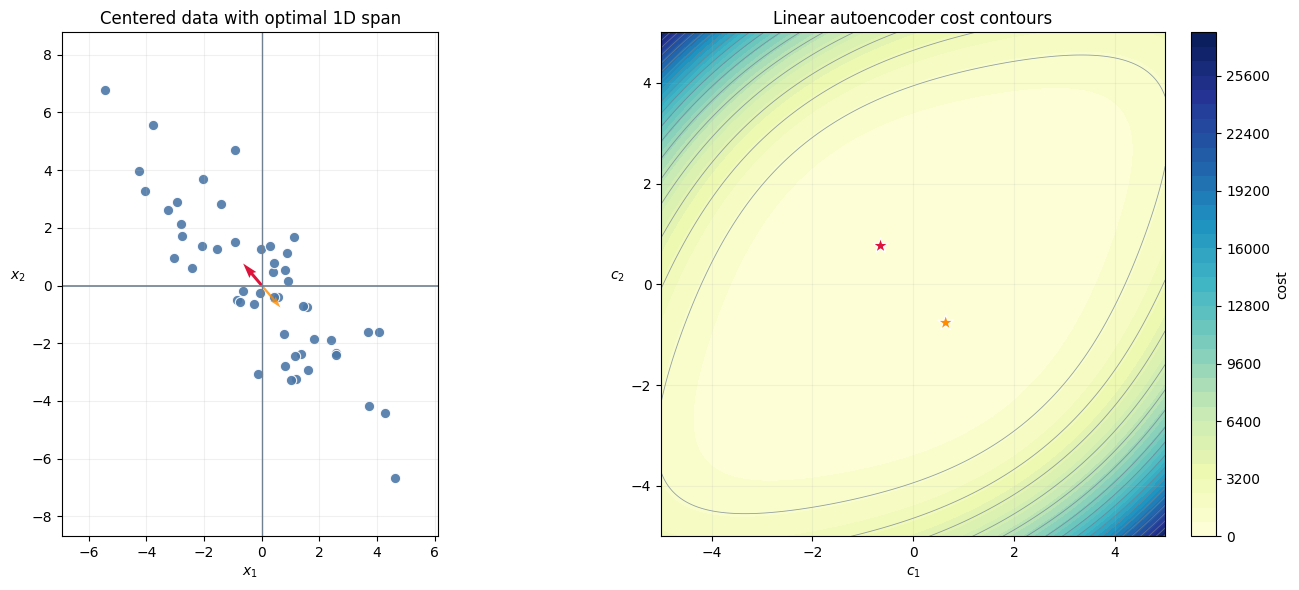

In [3]:
# QUESTION HANDLED: Exercise 8.4 - Nonconvexity of the linear Autoencoder.
# ---------------------------------------------------------------------
# Reproduce the Example 8.3 / Figure 8.5 style experiment for K = 1 by making
# a contour plot of the linear autoencoder cost from Equation (8.17) over the
# square [-5, 5] x [-5, 5].  The chapter discussion uses a mean-centered 2D
# toy dataset, so we center the Chapter 8 span dataset before fitting.
# ---------------------------------------------------------------------
# Textbook equations used here: the linear autoencoder reconstruction cost in
# Equation (8.17).

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
# HELPER IMPORTS AND FUNCTIONS FOR CHAPTER 8 EXERCISES.
# ---------------------------------------------------------------------
# This same cell collects the common imports, plotting configuration, dataset
# loaders, PCA helpers, linear-autoencoder helpers, and K-means helpers used
# across the Chapter 8 exercises so the later cells can stay focused on the
# exercise-specific logic.
# ---------------------------------------------------------------------

import numpy as np
import autograd.numpy as anp
from autograd import value_and_grad
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

SPAN_DATA_PATH = Path("..") / "chapter_8_datasets" / "2d_span_data.csv"
CLUSTER_DATA_PATH = Path("..") / "chapter_8_datasets" / "5cluster_2d_data.csv"

def load_span_data():
    return np.loadtxt(SPAN_DATA_PATH, delimiter=",")

def load_centered_span_data():
    X_raw = load_span_data()
    X_centered = X_raw - X_raw.mean(axis=1, keepdims=True)
    return X_raw, X_centered

def load_cluster_data():
    return np.loadtxt(CLUSTER_DATA_PATH, delimiter=",")

def center_data(X):
    X_means = np.mean(X, axis=1, keepdims=True)
    return X - X_means, X_means

def compute_pcs(X_centered, lam=0.0):
    num_points = float(X_centered.shape[1])
    covariance = (X_centered @ X_centered.T) / num_points + lam * np.eye(X_centered.shape[0])
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = np.argsort(eigenvalues)[::-1]
    return eigenvalues[order], eigenvectors[:, order]

def linear_autoencoder_cost_from_covariance(c, covariance):
    c = np.asarray(c).reshape(2, 1)
    quadratic_term = (c.T @ covariance @ c).item()
    norm_squared = (c.T @ c).item()
    return np.trace(covariance) - 2.0 * quadratic_term + norm_squared * quadratic_term

def linear_autoencoder_cost_autograd(c_flat, X_centered_ag):
    c = anp.reshape(c_flat, (2, 1))
    encoded_data = anp.dot(c.T, X_centered_ag)
    decoded_data = anp.dot(c, encoded_data)
    reconstruction_errors = decoded_data - X_centered_ag
    return anp.mean(anp.sum(reconstruction_errors ** 2, axis=0))

def gradient_descent_autograd(cost_fn, cost_and_grad_fn, c_init, alpha, max_its):
    c = anp.array(c_init, dtype=float)
    c_history = [np.asarray(c, dtype=float).copy()]
    cost_history = [float(cost_fn(c))]
    for _ in range(max_its):
        _, grad_value = cost_and_grad_fn(c)
        c = c - alpha * grad_value
        c_history.append(np.asarray(c, dtype=float).copy())
        cost_history.append(float(cost_fn(c)))
    return np.array(c_history), np.array(cost_history)

def assign_clusters(data, centroids):
    diffs = data[:, :, None] - centroids[:, None, :]
    squared_distances = np.sum(diffs ** 2, axis=0)
    return np.argmin(squared_distances, axis=1)

def update_centroids(data, assignments, old_centroids):
    centroids = old_centroids.copy()
    for k in range(old_centroids.shape[1]):
        cluster_points = data[:, assignments == k]
        if cluster_points.shape[1] > 0:
            centroids[:, k] = np.mean(cluster_points, axis=1)
    return centroids

def kmeans_objective(data, centroids, assignments):
    total_error = 0.0
    for k in range(centroids.shape[1]):
        cluster_points = data[:, assignments == k]
        if cluster_points.shape[1] > 0:
            diffs = cluster_points - centroids[:, [k]]
            total_error += np.sum(diffs ** 2)
    return total_error / data.shape[1]

def run_kmeans(data, init_centroids, max_its=50, return_history=False):
    centroids = init_centroids.copy()
    previous_assignments = None
    objective_history = []
    for _ in range(max_its):
        assignments = assign_clusters(data, centroids)
        objective_history.append(kmeans_objective(data, centroids, assignments))
        if previous_assignments is not None and np.array_equal(assignments, previous_assignments):
            break
        previous_assignments = assignments.copy()
        new_centroids = update_centroids(data, assignments, centroids)
        if np.allclose(new_centroids, centroids):
            centroids = new_centroids
            break
        centroids = new_centroids
    assignments = assign_clusters(data, centroids)
    final_objective = kmeans_objective(data, centroids, assignments)
    objective_history.append(final_objective)
    if return_history:
        return centroids, assignments, np.array(objective_history)
    return centroids, assignments, final_objective

_, X_ae = load_centered_span_data()
num_points = X_ae.shape[1]
S = (X_ae @ X_ae.T) / num_points

eigenvalues, principal_components = compute_pcs(X_ae)
principal_vector = principal_components[:, 0]
principal_vector = principal_vector / np.linalg.norm(principal_vector)
optimal_vectors = np.column_stack([principal_vector, -principal_vector])

w1_vals = np.linspace(-5, 5, 300)
w2_vals = np.linspace(-5, 5, 300)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
cost_surface = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        cost_surface[i, j] = linear_autoencoder_cost_from_covariance([W1[i, j], W2[i, j]], S)

grid_min_index = np.unravel_index(np.argmin(cost_surface), cost_surface.shape)
grid_min_location = np.array([W1[grid_min_index], W2[grid_min_index]])
grid_min_value = cost_surface[grid_min_index]

print(f"Centered data matrix shape: {X_ae.shape}")
print(f"Approximate grid minimum value: {grid_min_value:.4f}")
print(f"Approximate grid minimum location: {grid_min_location}")
print("The contour plot shows two symmetric global minima.")
print("These minima correspond to +v1 and -v1, the two orientations of the same optimal 1D span.")
print(f"First principal-component direction v1: {principal_vector}")
print("The spanning vector in the left panel matches one of these minima; the other is the same line reversed.")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_ae[0, :], X_ae[1, :], s=55, color="#4C78A8", edgecolor="white", linewidth=0.8, alpha=0.9)
axes[0].quiver(0, 0, principal_vector[0], principal_vector[1], angles="xy", scale_units="xy", scale=1, color="crimson", width=0.008)
axes[0].quiver(0, 0, -principal_vector[0], -principal_vector[1], angles="xy", scale_units="xy", scale=1, color="darkorange", width=0.006, alpha=0.8)
axes[0].axhline(0, color="slategray", linewidth=1.2)
axes[0].axvline(0, color="slategray", linewidth=1.0)
axes[0].set_title("Centered data with optimal 1D span")
axes[0].set_xlabel(r"$x_1$")
axes[0].set_ylabel(r"$x_2$", rotation=0, labelpad=10)
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(alpha=0.18)

xgap = 0.15 * (np.max(X_ae[0, :]) - np.min(X_ae[0, :]))
ygap = 0.15 * (np.max(X_ae[1, :]) - np.min(X_ae[1, :]))
axes[0].set_xlim(np.min(X_ae[0, :]) - xgap, np.max(X_ae[0, :]) + xgap)
axes[0].set_ylim(np.min(X_ae[1, :]) - ygap, np.max(X_ae[1, :]) + ygap)

filled = axes[1].contourf(W1, W2, cost_surface, levels=40, cmap="YlGnBu")
axes[1].contour(W1, W2, cost_surface, levels=20, colors=["slategray"], linewidths=0.6, alpha=0.75)
axes[1].scatter(optimal_vectors[0, :], optimal_vectors[1, :], s=140, color=["crimson", "darkorange"], marker="*", edgecolor="white", linewidth=0.9, zorder=3)
axes[1].set_title("Linear autoencoder cost contours")
axes[1].set_xlabel(r"$c_1$")
axes[1].set_ylabel(r"$c_2$", rotation=0, labelpad=10)
axes[1].set_xlim(-5, 5)
axes[1].set_ylim(-5, 5)
axes[1].set_aspect("equal", adjustable="box")
axes[1].grid(alpha=0.15)
fig.colorbar(filled, ax=axes[1], fraction=0.046, pad=0.04, label="cost")

plt.tight_layout()
plt.show()


Centered data matrix shape: (2, 50)
Initial cost: 10.3123
Best cost from gradient descent: 0.9966
Learned spanning vector: [ 0.65011472 -0.75983117]
Vector norm at the minimum: 0.999996
Absolute alignment with the first principal direction: 0.999988
Maximum reconstruction error after decoding: 1.7750


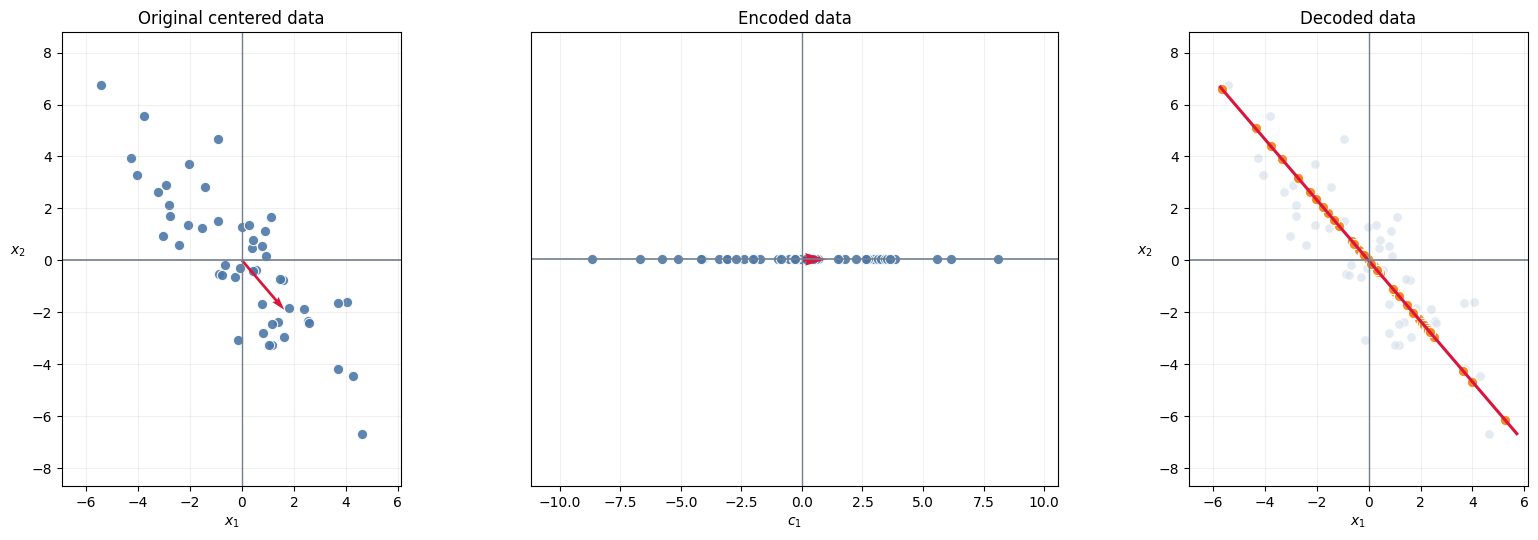

In [4]:
# QUESTION HANDLED: Exercise 8.5 - Minimizing the linear Autoencoder over a toy dataset.
# ---------------------------------------------------------------------
# Repeat Example 8.3 / Figure 8.5 by minimizing the K = 1 linear autoencoder
# cost on the Chapter 8 toy dataset.  The common autograd helpers live in the
# same cell, so this exercise cell can focus on the optimization setup and the
# resulting encoded / decoded views.
# ---------------------------------------------------------------------
# Textbook equations used here: the linear autoencoder reconstruction cost in
# Equation (8.17), differentiated below with autograd.

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
# HELPER IMPORTS AND FUNCTIONS FOR CHAPTER 8 EXERCISES.
# ---------------------------------------------------------------------
# This same cell collects the common imports, plotting configuration, dataset
# loaders, PCA helpers, linear-autoencoder helpers, and K-means helpers used
# across the Chapter 8 exercises so the later cells can stay focused on the
# exercise-specific logic.
# ---------------------------------------------------------------------

import numpy as np
import autograd.numpy as anp
from autograd import value_and_grad
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

SPAN_DATA_PATH = Path("..") / "chapter_8_datasets" / "2d_span_data.csv"
CLUSTER_DATA_PATH = Path("..") / "chapter_8_datasets" / "5cluster_2d_data.csv"

def load_span_data():
    return np.loadtxt(SPAN_DATA_PATH, delimiter=",")

def load_centered_span_data():
    X_raw = load_span_data()
    X_centered = X_raw - X_raw.mean(axis=1, keepdims=True)
    return X_raw, X_centered

def load_cluster_data():
    return np.loadtxt(CLUSTER_DATA_PATH, delimiter=",")

def center_data(X):
    X_means = np.mean(X, axis=1, keepdims=True)
    return X - X_means, X_means

def compute_pcs(X_centered, lam=0.0):
    num_points = float(X_centered.shape[1])
    covariance = (X_centered @ X_centered.T) / num_points + lam * np.eye(X_centered.shape[0])
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = np.argsort(eigenvalues)[::-1]
    return eigenvalues[order], eigenvectors[:, order]

def linear_autoencoder_cost_from_covariance(c, covariance):
    c = np.asarray(c).reshape(2, 1)
    quadratic_term = (c.T @ covariance @ c).item()
    norm_squared = (c.T @ c).item()
    return np.trace(covariance) - 2.0 * quadratic_term + norm_squared * quadratic_term

def linear_autoencoder_cost_autograd(c_flat, X_centered_ag):
    c = anp.reshape(c_flat, (2, 1))
    encoded_data = anp.dot(c.T, X_centered_ag)
    decoded_data = anp.dot(c, encoded_data)
    reconstruction_errors = decoded_data - X_centered_ag
    return anp.mean(anp.sum(reconstruction_errors ** 2, axis=0))

def gradient_descent_autograd(cost_fn, cost_and_grad_fn, c_init, alpha, max_its):
    c = anp.array(c_init, dtype=float)
    c_history = [np.asarray(c, dtype=float).copy()]
    cost_history = [float(cost_fn(c))]
    for _ in range(max_its):
        _, grad_value = cost_and_grad_fn(c)
        c = c - alpha * grad_value
        c_history.append(np.asarray(c, dtype=float).copy())
        cost_history.append(float(cost_fn(c)))
    return np.array(c_history), np.array(cost_history)

def assign_clusters(data, centroids):
    diffs = data[:, :, None] - centroids[:, None, :]
    squared_distances = np.sum(diffs ** 2, axis=0)
    return np.argmin(squared_distances, axis=1)

def update_centroids(data, assignments, old_centroids):
    centroids = old_centroids.copy()
    for k in range(old_centroids.shape[1]):
        cluster_points = data[:, assignments == k]
        if cluster_points.shape[1] > 0:
            centroids[:, k] = np.mean(cluster_points, axis=1)
    return centroids

def kmeans_objective(data, centroids, assignments):
    total_error = 0.0
    for k in range(centroids.shape[1]):
        cluster_points = data[:, assignments == k]
        if cluster_points.shape[1] > 0:
            diffs = cluster_points - centroids[:, [k]]
            total_error += np.sum(diffs ** 2)
    return total_error / data.shape[1]

def run_kmeans(data, init_centroids, max_its=50, return_history=False):
    centroids = init_centroids.copy()
    previous_assignments = None
    objective_history = []
    for _ in range(max_its):
        assignments = assign_clusters(data, centroids)
        objective_history.append(kmeans_objective(data, centroids, assignments))
        if previous_assignments is not None and np.array_equal(assignments, previous_assignments):
            break
        previous_assignments = assignments.copy()
        new_centroids = update_centroids(data, assignments, centroids)
        if np.allclose(new_centroids, centroids):
            centroids = new_centroids
            break
        centroids = new_centroids
    assignments = assign_clusters(data, centroids)
    final_objective = kmeans_objective(data, centroids, assignments)
    objective_history.append(final_objective)
    if return_history:
        return centroids, assignments, np.array(objective_history)
    return centroids, assignments, final_objective

_, X_centered = load_centered_span_data()
num_points = X_centered.shape[1]
X_centered_ag = anp.array(X_centered)

linear_autoencoder_cost = lambda c_flat: linear_autoencoder_cost_autograd(c_flat, X_centered_ag)
linear_autoencoder_cost_and_grad = value_and_grad(linear_autoencoder_cost)

initial_c = np.array([0.25, -0.20])
alpha = 5e-4
max_its = 300
c_history, cost_history = gradient_descent_autograd(
    linear_autoencoder_cost,
    linear_autoencoder_cost_and_grad,
    initial_c,
    alpha,
    max_its,
)

best_index = np.argmin(cost_history)
learned_c = c_history[best_index]
learned_direction = learned_c / np.linalg.norm(learned_c)
encoded_data = learned_c.reshape(1, 2) @ X_centered
decoded_data = learned_c.reshape(2, 1) @ encoded_data
max_reconstruction_error = np.max(np.abs(decoded_data - X_centered))

eigenvalues, principal_components = compute_pcs(X_centered)
principal_direction = principal_components[:, 0]
principal_direction = principal_direction / np.linalg.norm(principal_direction)
alignment = abs(principal_direction @ learned_direction)

print(f"Centered data matrix shape: {X_centered.shape}")
print(f"Initial cost: {cost_history[0]:.4f}")
print(f"Best cost from gradient descent: {cost_history[best_index]:.4f}")
print(f"Learned spanning vector: {learned_c}")
print(f"Vector norm at the minimum: {np.linalg.norm(learned_c):.6f}")
print(f"Absolute alignment with the first principal direction: {alignment:.6f}")
print(f"Maximum reconstruction error after decoding: {max_reconstruction_error:.4f}")

point_color = "#4C78A8"
decoded_color = "#F58518"
vector_color = "crimson"
axis_color = "slategray"
background_color = "#D9E2EC"

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

xmin, xmax = np.min(X_centered[0, :]), np.max(X_centered[0, :])
ymin, ymax = np.min(X_centered[1, :]), np.max(X_centered[1, :])
xgap = 0.15 * (xmax - xmin)
ygap = 0.15 * (ymax - ymin)
span_limit = max(abs(xmin - xgap), abs(xmax + xgap), abs(ymin - ygap), abs(ymax + ygap))
line_t = np.linspace(-span_limit, span_limit, 200)
subspace_line = learned_direction.reshape(2, 1) @ line_t.reshape(1, -1)
display_vector = 2.5 * learned_direction

axes[0].scatter(X_centered[0, :], X_centered[1, :], s=55, color=point_color, edgecolor="white", linewidth=0.8, alpha=0.9)
axes[0].quiver(0, 0, display_vector[0], display_vector[1], angles="xy", scale_units="xy", scale=1, color=vector_color, width=0.008)
axes[0].axhline(0, color=axis_color, linewidth=1.2)
axes[0].axvline(0, color=axis_color, linewidth=1.0)
axes[0].set_title("Original centered data")
axes[0].set_xlabel(r"$x_1$")
axes[0].set_ylabel(r"$x_2$", rotation=0, labelpad=10)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlim(xmin - xgap, xmax + xgap)
axes[0].set_ylim(ymin - ygap, ymax + ygap)
axes[0].grid(alpha=0.18)

axes[1].scatter(encoded_data[0, :], np.zeros(num_points), s=55, color=point_color, edgecolor="white", linewidth=0.8, alpha=0.9)
axes[1].axhline(0, color=axis_color, linewidth=1.2)
axes[1].axvline(0, color=axis_color, linewidth=1.0)
axes[1].quiver(0, 0, 1.0, 0, angles="xy", scale_units="xy", scale=1, color=vector_color, width=0.008)
axes[1].set_title("Encoded data")
axes[1].set_xlabel(r"$c_1$")
axes[1].set_yticks([])
axes[1].set_ylim(-0.75, 0.75)
encoded_min, encoded_max = np.min(encoded_data), np.max(encoded_data)
encoded_gap = 0.15 * (encoded_max - encoded_min)
axes[1].set_xlim(encoded_min - encoded_gap, encoded_max + encoded_gap)
axes[1].grid(alpha=0.18)

axes[2].scatter(X_centered[0, :], X_centered[1, :], s=45, color=background_color, edgecolor="white", linewidth=0.6, alpha=0.7)
axes[2].plot(subspace_line[0, :], subspace_line[1, :], color=vector_color, linewidth=2.2)
axes[2].scatter(decoded_data[0, :], decoded_data[1, :], s=55, color=decoded_color, edgecolor="white", linewidth=0.8, alpha=0.95)
axes[2].axhline(0, color=axis_color, linewidth=1.2)
axes[2].axvline(0, color=axis_color, linewidth=1.0)
axes[2].set_title("Decoded data")
axes[2].set_xlabel(r"$x_1$")
axes[2].set_ylabel(r"$x_2$", rotation=0, labelpad=10)
axes[2].set_aspect("equal", adjustable="box")
axes[2].set_xlim(xmin - xgap, xmax + xgap)
axes[2].set_ylim(ymin - ygap, ymax + ygap)
axes[2].grid(alpha=0.18)

plt.tight_layout()
plt.show()


Centered data matrix shape: (2, 50)
Principal variances: [11.47205837  0.99633819]
PCA basis matrix C:
[[-0.64634856 -0.7630423 ]
 [ 0.7630423  -0.64634856]]
Maximum orthogonality error: 2.01e-17
Maximum reconstruction error with the full PCA basis: 8.88e-16


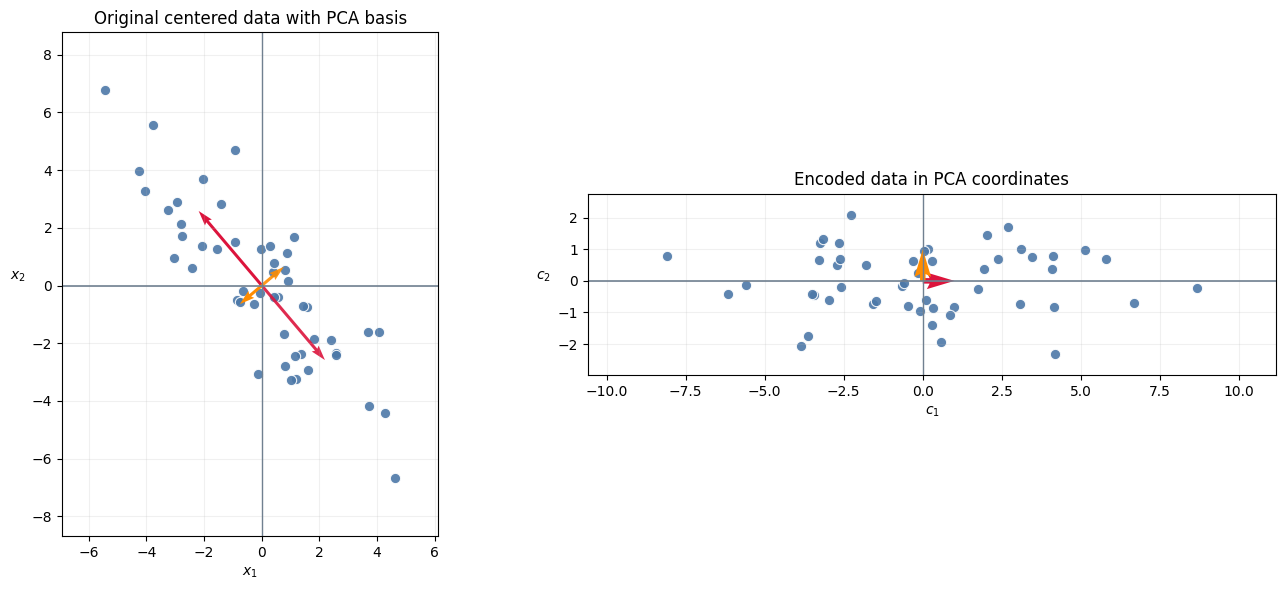

In [5]:
# QUESTION HANDLED: Exercise 8.6 - Producing a PCA basis.
# ---------------------------------------------------------------------
# Repeat Example 8.4 / Figure 8.7 by producing the PCA basis for the same
# mean-centered Chapter 8 toy dataset used in the linear autoencoder example.
# The left panel shows the centered data with both principal directions, and
# the right panel shows the encoded data after rotating into the PCA basis.
# ---------------------------------------------------------------------
# Textbook equations used here: the PCA least-squares factorization in Equation (8.29)
# and the compact PCA representation in Equation (8.30).

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
# HELPER IMPORTS AND FUNCTIONS FOR CHAPTER 8 EXERCISES.
# ---------------------------------------------------------------------
# This same cell collects the common imports, plotting configuration, dataset
# loaders, PCA helpers, linear-autoencoder helpers, and K-means helpers used
# across the Chapter 8 exercises so the later cells can stay focused on the
# exercise-specific logic.
# ---------------------------------------------------------------------

import numpy as np
import autograd.numpy as anp
from autograd import value_and_grad
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

SPAN_DATA_PATH = Path("..") / "chapter_8_datasets" / "2d_span_data.csv"
CLUSTER_DATA_PATH = Path("..") / "chapter_8_datasets" / "5cluster_2d_data.csv"

def load_span_data():
    return np.loadtxt(SPAN_DATA_PATH, delimiter=",")

def load_centered_span_data():
    X_raw = load_span_data()
    X_centered = X_raw - X_raw.mean(axis=1, keepdims=True)
    return X_raw, X_centered

def load_cluster_data():
    return np.loadtxt(CLUSTER_DATA_PATH, delimiter=",")

def center_data(X):
    X_means = np.mean(X, axis=1, keepdims=True)
    return X - X_means, X_means

def compute_pcs(X_centered, lam=0.0):
    num_points = float(X_centered.shape[1])
    covariance = (X_centered @ X_centered.T) / num_points + lam * np.eye(X_centered.shape[0])
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = np.argsort(eigenvalues)[::-1]
    return eigenvalues[order], eigenvectors[:, order]

def linear_autoencoder_cost_from_covariance(c, covariance):
    c = np.asarray(c).reshape(2, 1)
    quadratic_term = (c.T @ covariance @ c).item()
    norm_squared = (c.T @ c).item()
    return np.trace(covariance) - 2.0 * quadratic_term + norm_squared * quadratic_term

def linear_autoencoder_cost_autograd(c_flat, X_centered_ag):
    c = anp.reshape(c_flat, (2, 1))
    encoded_data = anp.dot(c.T, X_centered_ag)
    decoded_data = anp.dot(c, encoded_data)
    reconstruction_errors = decoded_data - X_centered_ag
    return anp.mean(anp.sum(reconstruction_errors ** 2, axis=0))

def gradient_descent_autograd(cost_fn, cost_and_grad_fn, c_init, alpha, max_its):
    c = anp.array(c_init, dtype=float)
    c_history = [np.asarray(c, dtype=float).copy()]
    cost_history = [float(cost_fn(c))]
    for _ in range(max_its):
        _, grad_value = cost_and_grad_fn(c)
        c = c - alpha * grad_value
        c_history.append(np.asarray(c, dtype=float).copy())
        cost_history.append(float(cost_fn(c)))
    return np.array(c_history), np.array(cost_history)

def assign_clusters(data, centroids):
    diffs = data[:, :, None] - centroids[:, None, :]
    squared_distances = np.sum(diffs ** 2, axis=0)
    return np.argmin(squared_distances, axis=1)

def update_centroids(data, assignments, old_centroids):
    centroids = old_centroids.copy()
    for k in range(old_centroids.shape[1]):
        cluster_points = data[:, assignments == k]
        if cluster_points.shape[1] > 0:
            centroids[:, k] = np.mean(cluster_points, axis=1)
    return centroids

def kmeans_objective(data, centroids, assignments):
    total_error = 0.0
    for k in range(centroids.shape[1]):
        cluster_points = data[:, assignments == k]
        if cluster_points.shape[1] > 0:
            diffs = cluster_points - centroids[:, [k]]
            total_error += np.sum(diffs ** 2)
    return total_error / data.shape[1]

def run_kmeans(data, init_centroids, max_its=50, return_history=False):
    centroids = init_centroids.copy()
    previous_assignments = None
    objective_history = []
    for _ in range(max_its):
        assignments = assign_clusters(data, centroids)
        objective_history.append(kmeans_objective(data, centroids, assignments))
        if previous_assignments is not None and np.array_equal(assignments, previous_assignments):
            break
        previous_assignments = assignments.copy()
        new_centroids = update_centroids(data, assignments, centroids)
        if np.allclose(new_centroids, centroids):
            centroids = new_centroids
            break
        centroids = new_centroids
    assignments = assign_clusters(data, centroids)
    final_objective = kmeans_objective(data, centroids, assignments)
    objective_history.append(final_objective)
    if return_history:
        return centroids, assignments, np.array(objective_history)
    return centroids, assignments, final_objective

_, X_centered = load_centered_span_data()
num_points = X_centered.shape[1]

eigenvalues, C_pca = compute_pcs(X_centered)
W_pca = C_pca.T @ X_centered
X_reconstructed = C_pca @ W_pca
max_reconstruction_error = np.max(np.abs(X_centered - X_reconstructed))
orthogonality_error = np.max(np.abs(C_pca.T @ C_pca - np.eye(2)))
pc1_display = np.sqrt(eigenvalues[0]) * C_pca[:, 0]
pc2_display = np.sqrt(eigenvalues[1]) * C_pca[:, 1]

print(f"Centered data matrix shape: {X_centered.shape}")
print(f"Principal variances: {eigenvalues}")
print("PCA basis matrix C:")
print(C_pca)
print(f"Maximum orthogonality error: {orthogonality_error:.2e}")
print(f"Maximum reconstruction error with the full PCA basis: {max_reconstruction_error:.2e}")

point_color = "#4C78A8"
pc1_color = "crimson"
pc2_color = "darkorange"
axis_color = "slategray"

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_centered[0, :], X_centered[1, :], s=55, color=point_color, edgecolor="white", linewidth=0.8, alpha=0.9)
axes[0].quiver(0, 0, pc1_display[0], pc1_display[1], angles="xy", scale_units="xy", scale=1, color=pc1_color, width=0.008)
axes[0].quiver(0, 0, -pc1_display[0], -pc1_display[1], angles="xy", scale_units="xy", scale=1, color=pc1_color, width=0.008, alpha=0.9)
axes[0].quiver(0, 0, pc2_display[0], pc2_display[1], angles="xy", scale_units="xy", scale=1, color=pc2_color, width=0.008)
axes[0].quiver(0, 0, -pc2_display[0], -pc2_display[1], angles="xy", scale_units="xy", scale=1, color=pc2_color, width=0.008, alpha=0.9)
axes[0].axhline(0, color=axis_color, linewidth=1.2)
axes[0].axvline(0, color=axis_color, linewidth=1.0)
axes[0].set_title("Original centered data with PCA basis")
axes[0].set_xlabel(r"$x_1$")
axes[0].set_ylabel(r"$x_2$", rotation=0, labelpad=10)
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(alpha=0.18)

xmin, xmax = np.min(X_centered[0, :]), np.max(X_centered[0, :])
ymin, ymax = np.min(X_centered[1, :]), np.max(X_centered[1, :])
xgap = 0.15 * (xmax - xmin)
ygap = 0.15 * (ymax - ymin)
axes[0].set_xlim(xmin - xgap, xmax + xgap)
axes[0].set_ylim(ymin - ygap, ymax + ygap)

axes[1].scatter(W_pca[0, :], W_pca[1, :], s=55, color=point_color, edgecolor="white", linewidth=0.8, alpha=0.9)
axes[1].quiver(0, 0, 1.0, 0, angles="xy", scale_units="xy", scale=1, color=pc1_color, width=0.008)
axes[1].quiver(0, 0, 0, 1.0, angles="xy", scale_units="xy", scale=1, color=pc2_color, width=0.008)
axes[1].axhline(0, color=axis_color, linewidth=1.2)
axes[1].axvline(0, color=axis_color, linewidth=1.0)
axes[1].set_title("Encoded data in PCA coordinates")
axes[1].set_xlabel(r"$c_1$")
axes[1].set_ylabel(r"$c_2$", rotation=0, labelpad=10)
axes[1].set_aspect("equal", adjustable="box")
axes[1].grid(alpha=0.18)

xmin_w, xmax_w = np.min(W_pca[0, :]), np.max(W_pca[0, :])
ymin_w, ymax_w = np.min(W_pca[1, :]), np.max(W_pca[1, :])
xgap_w = 0.15 * (xmax_w - xmin_w)
ygap_w = 0.15 * (ymax_w - ymin_w)
axes[1].set_xlim(xmin_w - xgap_w, xmax_w + xgap_w)
axes[1].set_ylim(ymin_w - ygap_w, ymax_w + ygap_w)

plt.tight_layout()
plt.show()


Dataset shape: (2, 160)
Leading PCA variances: [4.37674774 1.43991995]
Leading PCA direction: [-0.99936967  0.03550028]
Best threshold mistakes in the original plane: 0
Best threshold mistakes after projection onto the 1D PCA subspace: 70


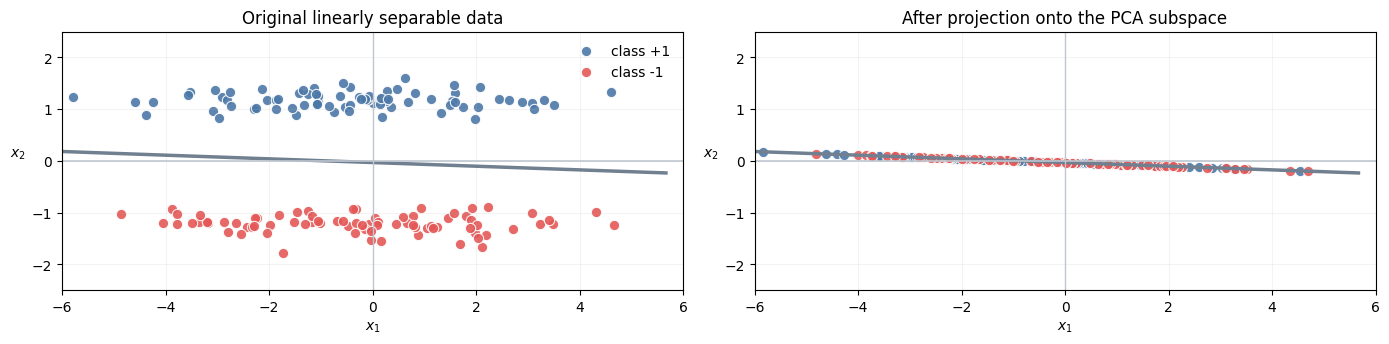

In [6]:
# QUESTION HANDLED: Exercise 8.7 - A warning example.
# ---------------------------------------------------------------------
# Repeat Example 8.5 / Figure 8.8 by showing how PCA can be a poor choice for
# dimension reduction in a classification problem.  The synthetic two-class
# dataset below is linearly separable in 2D, but its largest direction of
# overall variance runs almost parallel to the ideal separating boundary.
# Projecting onto that one-dimensional PCA subspace therefore destroys the
# class separation.
# ---------------------------------------------------------------------
# Textbook equations used here: the PCA basis / encoding viewpoint of Example 8.4,
# using the same principal-component construction tied to Equations (8.29) and (8.30).

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
# HELPER IMPORTS AND FUNCTIONS FOR CHAPTER 8 EXERCISES.
# ---------------------------------------------------------------------
# This same cell collects the common imports, plotting configuration, dataset
# loaders, PCA helpers, linear-autoencoder helpers, and K-means helpers used
# across the Chapter 8 exercises so the later cells can stay focused on the
# exercise-specific logic.
# ---------------------------------------------------------------------

import numpy as np
import autograd.numpy as anp
from autograd import value_and_grad
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

SPAN_DATA_PATH = Path("..") / "chapter_8_datasets" / "2d_span_data.csv"
CLUSTER_DATA_PATH = Path("..") / "chapter_8_datasets" / "5cluster_2d_data.csv"

def load_span_data():
    return np.loadtxt(SPAN_DATA_PATH, delimiter=",")

def load_centered_span_data():
    X_raw = load_span_data()
    X_centered = X_raw - X_raw.mean(axis=1, keepdims=True)
    return X_raw, X_centered

def load_cluster_data():
    return np.loadtxt(CLUSTER_DATA_PATH, delimiter=",")

def center_data(X):
    X_means = np.mean(X, axis=1, keepdims=True)
    return X - X_means, X_means

def compute_pcs(X_centered, lam=0.0):
    num_points = float(X_centered.shape[1])
    covariance = (X_centered @ X_centered.T) / num_points + lam * np.eye(X_centered.shape[0])
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = np.argsort(eigenvalues)[::-1]
    return eigenvalues[order], eigenvectors[:, order]

def linear_autoencoder_cost_from_covariance(c, covariance):
    c = np.asarray(c).reshape(2, 1)
    quadratic_term = (c.T @ covariance @ c).item()
    norm_squared = (c.T @ c).item()
    return np.trace(covariance) - 2.0 * quadratic_term + norm_squared * quadratic_term

def linear_autoencoder_cost_autograd(c_flat, X_centered_ag):
    c = anp.reshape(c_flat, (2, 1))
    encoded_data = anp.dot(c.T, X_centered_ag)
    decoded_data = anp.dot(c, encoded_data)
    reconstruction_errors = decoded_data - X_centered_ag
    return anp.mean(anp.sum(reconstruction_errors ** 2, axis=0))

def gradient_descent_autograd(cost_fn, cost_and_grad_fn, c_init, alpha, max_its):
    c = anp.array(c_init, dtype=float)
    c_history = [np.asarray(c, dtype=float).copy()]
    cost_history = [float(cost_fn(c))]
    for _ in range(max_its):
        _, grad_value = cost_and_grad_fn(c)
        c = c - alpha * grad_value
        c_history.append(np.asarray(c, dtype=float).copy())
        cost_history.append(float(cost_fn(c)))
    return np.array(c_history), np.array(cost_history)

def assign_clusters(data, centroids):
    diffs = data[:, :, None] - centroids[:, None, :]
    squared_distances = np.sum(diffs ** 2, axis=0)
    return np.argmin(squared_distances, axis=1)

def update_centroids(data, assignments, old_centroids):
    centroids = old_centroids.copy()
    for k in range(old_centroids.shape[1]):
        cluster_points = data[:, assignments == k]
        if cluster_points.shape[1] > 0:
            centroids[:, k] = np.mean(cluster_points, axis=1)
    return centroids

def kmeans_objective(data, centroids, assignments):
    total_error = 0.0
    for k in range(centroids.shape[1]):
        cluster_points = data[:, assignments == k]
        if cluster_points.shape[1] > 0:
            diffs = cluster_points - centroids[:, [k]]
            total_error += np.sum(diffs ** 2)
    return total_error / data.shape[1]

def run_kmeans(data, init_centroids, max_its=50, return_history=False):
    centroids = init_centroids.copy()
    previous_assignments = None
    objective_history = []
    for _ in range(max_its):
        assignments = assign_clusters(data, centroids)
        objective_history.append(kmeans_objective(data, centroids, assignments))
        if previous_assignments is not None and np.array_equal(assignments, previous_assignments):
            break
        previous_assignments = assignments.copy()
        new_centroids = update_centroids(data, assignments, centroids)
        if np.allclose(new_centroids, centroids):
            centroids = new_centroids
            break
        centroids = new_centroids
    assignments = assign_clusters(data, centroids)
    final_objective = kmeans_objective(data, centroids, assignments)
    objective_history.append(final_objective)
    if return_history:
        return centroids, assignments, np.array(objective_history)
    return centroids, assignments, final_objective

def best_threshold_mistakes(scores, labels):
    thresholds = np.linspace(np.min(scores), np.max(scores), 2001)
    best_errors = labels.size
    for threshold in thresholds:
        predictions = np.where(scores >= threshold, 1, -1)
        best_errors = min(
            best_errors,
            np.sum(predictions != labels),
            np.sum(-predictions != labels),
        )
    return int(best_errors)

rng = np.random.default_rng(7)
num_per_class = 80
class_pos = np.vstack([
    rng.normal(loc=0.0, scale=2.3, size=num_per_class),
    rng.normal(loc=1.2, scale=0.18, size=num_per_class),
])
class_neg = np.vstack([
    rng.normal(loc=0.0, scale=2.3, size=num_per_class),
    rng.normal(loc=-1.2, scale=0.18, size=num_per_class),
])

X = np.hstack([class_pos, class_neg])
y = np.hstack([np.ones(num_per_class, dtype=int), -np.ones(num_per_class, dtype=int)])

X_centered, X_mean = center_data(X)
eigenvalues, principal_components = compute_pcs(X_centered, lam=1e-7)
principal_direction = principal_components[:, 0]
encoded_scores = principal_direction.reshape(1, 2) @ X_centered
X_projected = X_mean + principal_direction.reshape(2, 1) @ encoded_scores

original_plane_mistakes = best_threshold_mistakes(X[1, :], y)
projected_1d_mistakes = best_threshold_mistakes(encoded_scores.ravel(), y)

print(f"Dataset shape: {X.shape}")
print(f"Leading PCA variances: {eigenvalues[:2]}")
print(f"Leading PCA direction: {principal_direction}")
print(f"Best threshold mistakes in the original plane: {original_plane_mistakes}")
print(f"Best threshold mistakes after projection onto the 1D PCA subspace: {projected_1d_mistakes}")

positive_color = "#4C78A8"
negative_color = "#E45756"
subspace_color = "slategray"
axis_color = "#BFC6CF"

line_t = np.linspace(-6.0, 6.0, 300)
pca_line = X_mean + principal_direction.reshape(2, 1) @ line_t.reshape(1, -1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, data, title in [
    (axes[0], X, "Original linearly separable data"),
    (axes[1], X_projected, "After projection onto the PCA subspace"),
]:
    ax.scatter(data[0, y == 1], data[1, y == 1], s=55, color=positive_color, edgecolor="white", linewidth=0.8, alpha=0.9, label="class +1")
    ax.scatter(data[0, y == -1], data[1, y == -1], s=55, color=negative_color, edgecolor="white", linewidth=0.8, alpha=0.9, label="class -1")
    ax.plot(pca_line[0, :], pca_line[1, :], color=subspace_color, linewidth=2.5)
    ax.axhline(0, color=axis_color, linewidth=1.2)
    ax.axvline(0, color=axis_color, linewidth=1.0)
    ax.set_title(title)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$", rotation=0, labelpad=10)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-6, 6)
    ax.set_ylim(-2.5, 2.5)
    ax.grid(alpha=0.14)

axes[0].legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.show()


Loaded dataset shape: (2, 53)
Chosen restart: 9
Final average squared-distance objective: 0.4527
Cluster sizes: [20 20 13]
Final centroid locations:
[[ 0.62852007 -1.02677947  0.43443996]
 [ 0.94484752  0.21113441 -0.72067446]]


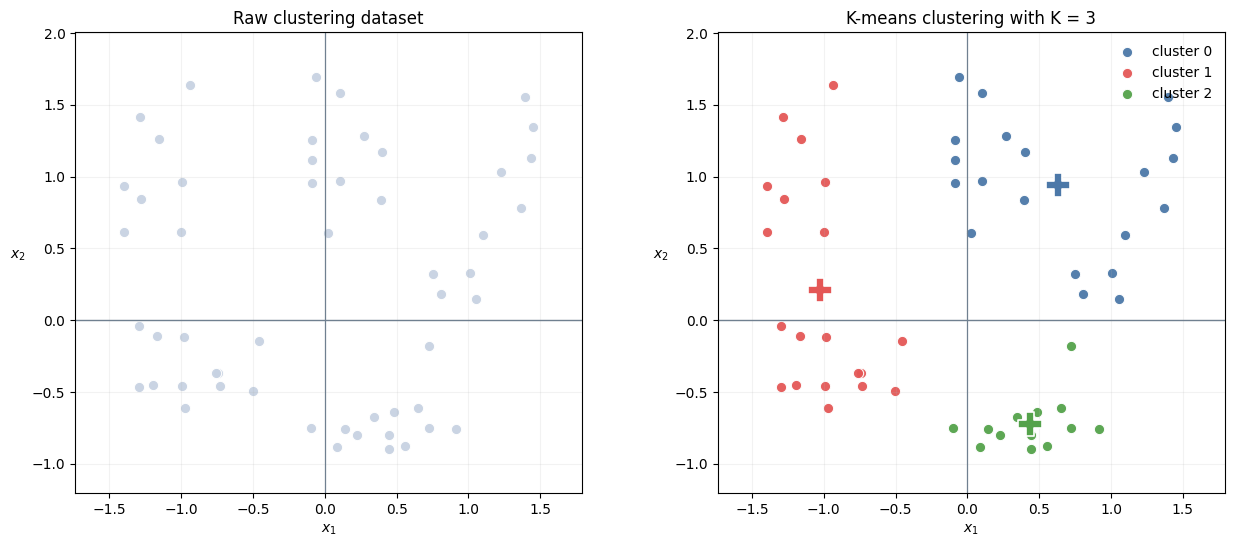

In [7]:
# QUESTION HANDLED: Exercise 8.8 - Perform K-means.
# ---------------------------------------------------------------------
# Implement the K-means algorithm from Section 8.5 and apply it to the local
# Chapter 8 clustering dataset used for Figure 8.13.  We use K = 3 centroids,
# run several random initializations because K-means is initialization-
# sensitive, and keep the run with the smallest final clustering objective.
# ---------------------------------------------------------------------
# Textbook equations used here: the K-means quality measure based on the average
# intra-cluster distance in Equation (8.28).

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
# HELPER IMPORTS AND FUNCTIONS FOR CHAPTER 8 EXERCISES.
# ---------------------------------------------------------------------
# This same cell collects the common imports, plotting configuration, dataset
# loaders, PCA helpers, linear-autoencoder helpers, and K-means helpers used
# across the Chapter 8 exercises so the later cells can stay focused on the
# exercise-specific logic.
# ---------------------------------------------------------------------

import numpy as np
import autograd.numpy as anp
from autograd import value_and_grad
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

SPAN_DATA_PATH = Path("..") / "chapter_8_datasets" / "2d_span_data.csv"
CLUSTER_DATA_PATH = Path("..") / "chapter_8_datasets" / "5cluster_2d_data.csv"

def load_span_data():
    return np.loadtxt(SPAN_DATA_PATH, delimiter=",")

def load_centered_span_data():
    X_raw = load_span_data()
    X_centered = X_raw - X_raw.mean(axis=1, keepdims=True)
    return X_raw, X_centered

def load_cluster_data():
    return np.loadtxt(CLUSTER_DATA_PATH, delimiter=",")

def center_data(X):
    X_means = np.mean(X, axis=1, keepdims=True)
    return X - X_means, X_means

def compute_pcs(X_centered, lam=0.0):
    num_points = float(X_centered.shape[1])
    covariance = (X_centered @ X_centered.T) / num_points + lam * np.eye(X_centered.shape[0])
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = np.argsort(eigenvalues)[::-1]
    return eigenvalues[order], eigenvectors[:, order]

def linear_autoencoder_cost_from_covariance(c, covariance):
    c = np.asarray(c).reshape(2, 1)
    quadratic_term = (c.T @ covariance @ c).item()
    norm_squared = (c.T @ c).item()
    return np.trace(covariance) - 2.0 * quadratic_term + norm_squared * quadratic_term

def linear_autoencoder_cost_autograd(c_flat, X_centered_ag):
    c = anp.reshape(c_flat, (2, 1))
    encoded_data = anp.dot(c.T, X_centered_ag)
    decoded_data = anp.dot(c, encoded_data)
    reconstruction_errors = decoded_data - X_centered_ag
    return anp.mean(anp.sum(reconstruction_errors ** 2, axis=0))

def gradient_descent_autograd(cost_fn, cost_and_grad_fn, c_init, alpha, max_its):
    c = anp.array(c_init, dtype=float)
    c_history = [np.asarray(c, dtype=float).copy()]
    cost_history = [float(cost_fn(c))]
    for _ in range(max_its):
        _, grad_value = cost_and_grad_fn(c)
        c = c - alpha * grad_value
        c_history.append(np.asarray(c, dtype=float).copy())
        cost_history.append(float(cost_fn(c)))
    return np.array(c_history), np.array(cost_history)

def assign_clusters(data, centroids):
    diffs = data[:, :, None] - centroids[:, None, :]
    squared_distances = np.sum(diffs ** 2, axis=0)
    return np.argmin(squared_distances, axis=1)

def update_centroids(data, assignments, old_centroids):
    centroids = old_centroids.copy()
    for k in range(old_centroids.shape[1]):
        cluster_points = data[:, assignments == k]
        if cluster_points.shape[1] > 0:
            centroids[:, k] = np.mean(cluster_points, axis=1)
    return centroids

def kmeans_objective(data, centroids, assignments):
    total_error = 0.0
    for k in range(centroids.shape[1]):
        cluster_points = data[:, assignments == k]
        if cluster_points.shape[1] > 0:
            diffs = cluster_points - centroids[:, [k]]
            total_error += np.sum(diffs ** 2)
    return total_error / data.shape[1]

def run_kmeans(data, init_centroids, max_its=50, return_history=False):
    centroids = init_centroids.copy()
    previous_assignments = None
    objective_history = []
    for _ in range(max_its):
        assignments = assign_clusters(data, centroids)
        objective_history.append(kmeans_objective(data, centroids, assignments))
        if previous_assignments is not None and np.array_equal(assignments, previous_assignments):
            break
        previous_assignments = assignments.copy()
        new_centroids = update_centroids(data, assignments, centroids)
        if np.allclose(new_centroids, centroids):
            centroids = new_centroids
            break
        centroids = new_centroids
    assignments = assign_clusters(data, centroids)
    final_objective = kmeans_objective(data, centroids, assignments)
    objective_history.append(final_objective)
    if return_history:
        return centroids, assignments, np.array(objective_history)
    return centroids, assignments, final_objective

X = load_cluster_data()
num_points = X.shape[1]
num_clusters = 3

rng = np.random.default_rng(12)
num_restarts = 50
best_result = None

for restart in range(num_restarts):
    init_indices = rng.choice(num_points, size=num_clusters, replace=False)
    init_centroids = X[:, init_indices]
    centroids, assignments, objective_history = run_kmeans(X, init_centroids, return_history=True)
    final_objective = objective_history[-1]

    if best_result is None or final_objective < best_result["final_objective"]:
        best_result = {
            "restart": restart,
            "init_indices": init_indices,
            "centroids": centroids,
            "assignments": assignments,
            "objective_history": objective_history,
            "final_objective": final_objective,
        }

final_centroids = best_result["centroids"]
final_assignments = best_result["assignments"]
cluster_sizes = np.bincount(final_assignments, minlength=num_clusters)

print(f"Loaded dataset shape: {X.shape}")
print(f"Chosen restart: {best_result['restart']}")
print(f"Final average squared-distance objective: {best_result['final_objective']:.4f}")
print(f"Cluster sizes: {cluster_sizes}")
print("Final centroid locations:")
print(final_centroids)

raw_color = "#C7D2E2"
cluster_colors = ["#4C78A8", "#E45756", "#54A24B"]
centroid_marker = "P"
axis_color = "slategray"

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].scatter(X[0, :], X[1, :], s=55, color=raw_color, edgecolor="white", linewidth=0.8, alpha=0.95)
axes[0].axhline(0, color=axis_color, linewidth=1.0)
axes[0].axvline(0, color=axis_color, linewidth=0.9)
axes[0].set_title("Raw clustering dataset")
axes[0].set_xlabel(r"$x_1$")
axes[0].set_ylabel(r"$x_2$", rotation=0, labelpad=10)
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(alpha=0.16)

for k, color in enumerate(cluster_colors):
    cluster_points = X[:, final_assignments == k]
    axes[1].scatter(cluster_points[0, :], cluster_points[1, :], s=55, color=color, edgecolor="white", linewidth=0.8, alpha=0.95, label=f"cluster {k}")
    axes[1].scatter(final_centroids[0, k], final_centroids[1, k], s=300, color=color, marker=centroid_marker, edgecolor="white", linewidth=1.2, zorder=3)

axes[1].axhline(0, color=axis_color, linewidth=1.0)
axes[1].axvline(0, color=axis_color, linewidth=0.9)
axes[1].set_title("K-means clustering with K = 3")
axes[1].set_xlabel(r"$x_1$")
axes[1].set_ylabel(r"$x_2$", rotation=0, labelpad=10)
axes[1].set_aspect("equal", adjustable="box")
axes[1].grid(alpha=0.16)
axes[1].legend(frameon=False, loc="upper right")

xmin, xmax = np.min(X[0, :]), np.max(X[0, :])
ymin, ymax = np.min(X[1, :]), np.max(X[1, :])
xgap = 0.12 * (xmax - xmin)
ygap = 0.12 * (ymax - ymin)
for ax in axes:
    ax.set_xlim(xmin - xgap, xmax + xgap)
    ax.set_ylim(ymin - ygap, ymax + ygap)

plt.tight_layout()
plt.show()


Dataset shape: (2, 53)
K values evaluated: [1 2 3 4 5 6]
Best objectives: [1.45774336 0.86337861 0.45367966 0.27519786 0.15329754 0.10712476]
Largest drop occurs from K = 1 to K = 2


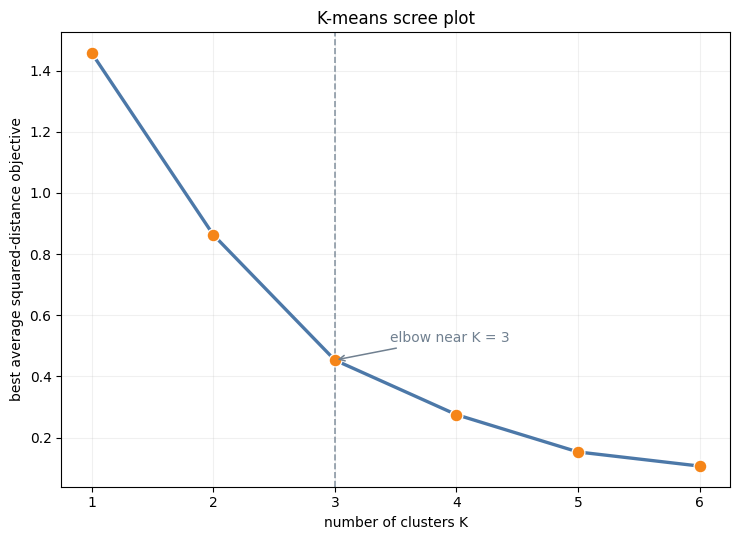

In [8]:
# QUESTION HANDLED: Exercise 8.9 - Making a scree plot.
# ---------------------------------------------------------------------
# Repeat Example 8.7 by computing a scree plot for K-means on the same local
# Chapter 8 clustering dataset used in Exercise 8.8.  For each K we run K-means
# multiple times from different random initializations and keep the smallest
# final objective, mirroring the way the chapter uses the K-means cost to judge
# how the fit improves as the number of clusters increases.
# ---------------------------------------------------------------------
# Textbook equations used here: the scree-plot criterion based on the average
# intra-cluster distance in Equation (8.28).

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
# HELPER IMPORTS AND FUNCTIONS FOR CHAPTER 8 EXERCISES.
# ---------------------------------------------------------------------
# This same cell collects the common imports, plotting configuration, dataset
# loaders, PCA helpers, linear-autoencoder helpers, and K-means helpers used
# across the Chapter 8 exercises so the later cells can stay focused on the
# exercise-specific logic.
# ---------------------------------------------------------------------

import numpy as np
import autograd.numpy as anp
from autograd import value_and_grad
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

SPAN_DATA_PATH = Path("..") / "chapter_8_datasets" / "2d_span_data.csv"
CLUSTER_DATA_PATH = Path("..") / "chapter_8_datasets" / "5cluster_2d_data.csv"

def load_span_data():
    return np.loadtxt(SPAN_DATA_PATH, delimiter=",")

def load_centered_span_data():
    X_raw = load_span_data()
    X_centered = X_raw - X_raw.mean(axis=1, keepdims=True)
    return X_raw, X_centered

def load_cluster_data():
    return np.loadtxt(CLUSTER_DATA_PATH, delimiter=",")

def center_data(X):
    X_means = np.mean(X, axis=1, keepdims=True)
    return X - X_means, X_means

def compute_pcs(X_centered, lam=0.0):
    num_points = float(X_centered.shape[1])
    covariance = (X_centered @ X_centered.T) / num_points + lam * np.eye(X_centered.shape[0])
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = np.argsort(eigenvalues)[::-1]
    return eigenvalues[order], eigenvectors[:, order]

def linear_autoencoder_cost_from_covariance(c, covariance):
    c = np.asarray(c).reshape(2, 1)
    quadratic_term = (c.T @ covariance @ c).item()
    norm_squared = (c.T @ c).item()
    return np.trace(covariance) - 2.0 * quadratic_term + norm_squared * quadratic_term

def linear_autoencoder_cost_autograd(c_flat, X_centered_ag):
    c = anp.reshape(c_flat, (2, 1))
    encoded_data = anp.dot(c.T, X_centered_ag)
    decoded_data = anp.dot(c, encoded_data)
    reconstruction_errors = decoded_data - X_centered_ag
    return anp.mean(anp.sum(reconstruction_errors ** 2, axis=0))

def gradient_descent_autograd(cost_fn, cost_and_grad_fn, c_init, alpha, max_its):
    c = anp.array(c_init, dtype=float)
    c_history = [np.asarray(c, dtype=float).copy()]
    cost_history = [float(cost_fn(c))]
    for _ in range(max_its):
        _, grad_value = cost_and_grad_fn(c)
        c = c - alpha * grad_value
        c_history.append(np.asarray(c, dtype=float).copy())
        cost_history.append(float(cost_fn(c)))
    return np.array(c_history), np.array(cost_history)

def assign_clusters(data, centroids):
    diffs = data[:, :, None] - centroids[:, None, :]
    squared_distances = np.sum(diffs ** 2, axis=0)
    return np.argmin(squared_distances, axis=1)

def update_centroids(data, assignments, old_centroids):
    centroids = old_centroids.copy()
    for k in range(old_centroids.shape[1]):
        cluster_points = data[:, assignments == k]
        if cluster_points.shape[1] > 0:
            centroids[:, k] = np.mean(cluster_points, axis=1)
    return centroids

def kmeans_objective(data, centroids, assignments):
    total_error = 0.0
    for k in range(centroids.shape[1]):
        cluster_points = data[:, assignments == k]
        if cluster_points.shape[1] > 0:
            diffs = cluster_points - centroids[:, [k]]
            total_error += np.sum(diffs ** 2)
    return total_error / data.shape[1]

def run_kmeans(data, init_centroids, max_its=50, return_history=False):
    centroids = init_centroids.copy()
    previous_assignments = None
    objective_history = []
    for _ in range(max_its):
        assignments = assign_clusters(data, centroids)
        objective_history.append(kmeans_objective(data, centroids, assignments))
        if previous_assignments is not None and np.array_equal(assignments, previous_assignments):
            break
        previous_assignments = assignments.copy()
        new_centroids = update_centroids(data, assignments, centroids)
        if np.allclose(new_centroids, centroids):
            centroids = new_centroids
            break
        centroids = new_centroids
    assignments = assign_clusters(data, centroids)
    final_objective = kmeans_objective(data, centroids, assignments)
    objective_history.append(final_objective)
    if return_history:
        return centroids, assignments, np.array(objective_history)
    return centroids, assignments, final_objective

X = load_cluster_data()
num_points = X.shape[1]

K_values = np.arange(1, 7)
num_restarts = 25
rng = np.random.default_rng(21)
best_objectives = []

for K in K_values:
    best_objective_for_K = np.inf
    for _ in range(num_restarts):
        init_indices = rng.choice(num_points, size=K, replace=False)
        init_centroids = X[:, init_indices]
        _, _, final_objective = run_kmeans(X, init_centroids)
        best_objective_for_K = min(best_objective_for_K, final_objective)
    best_objectives.append(best_objective_for_K)

best_objectives = np.array(best_objectives)
largest_drop_index = int(np.argmin(np.diff(best_objectives)))

print(f"Dataset shape: {X.shape}")
print(f"K values evaluated: {K_values}")
print(f"Best objectives: {best_objectives}")
print(f"Largest drop occurs from K = {K_values[largest_drop_index]} to K = {K_values[largest_drop_index + 1]}")

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(K_values, best_objectives, color="#4C78A8", linewidth=2.4)
ax.scatter(K_values, best_objectives, s=85, color="#F58518", edgecolor="white", linewidth=0.9, zorder=3)
ax.set_title("K-means scree plot")
ax.set_xlabel("number of clusters K")
ax.set_ylabel("best average squared-distance objective")
ax.set_xticks(K_values)
ax.grid(alpha=0.18)
ax.axvline(3, color="slategray", linestyle="--", linewidth=1.2, alpha=0.8)
ax.annotate(
    "elbow near K = 3",
    xy=(3, best_objectives[2]),
    xytext=(3.45, best_objectives[1] - 0.35),
    arrowprops=dict(arrowstyle="->", color="slategray", lw=1.1),
    color="slategray",
)

plt.tight_layout()
plt.show()
